# PROCESAMIENTO DE LENGUAJE NATURAL
El procesamiento del lenguaje natural (NLP) es una rama de la inteligencia artificial que permite a las máquinas entender, interpretar y manipular el lenguaje humano.

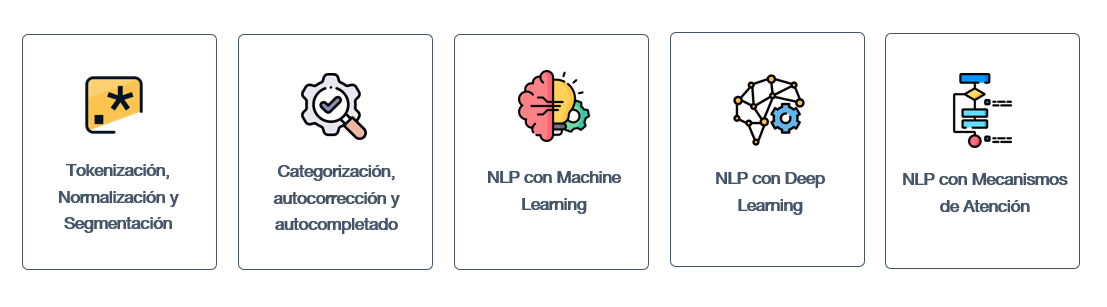

# Caso Análisis de Sentimientos

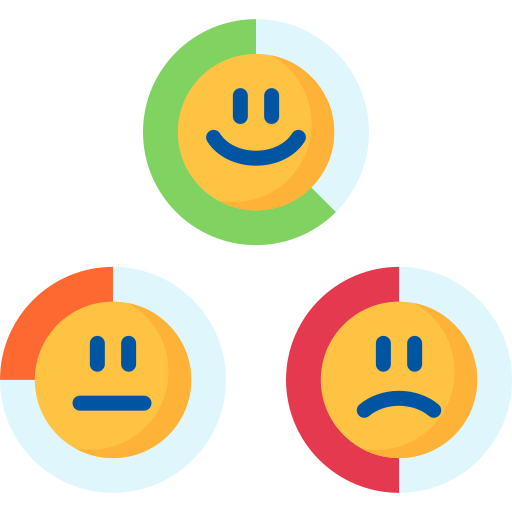

## IMDB Dataset

### Descripción General
El dataset de IMDB contiene reseñas de películas extraídas de la base de datos de películas en Internet (IMDB). Es ampliamente utilizado en el campo del procesamiento del lenguaje natural para tareas de análisis de sentimientos. Este conjunto de datos es particularmente útil para entrenar y evaluar modelos de clasificación de texto que determinan si una reseña es positiva o negativa.

### Características del Dataset
- **Número de Reseñas**: Generalmente, el dataset incluye 50,000 reseñas de películas, divididas equitativamente en dos conjuntos: entrenamiento y prueba.
- **Etiquetado Binario**: Cada reseña ha sido etiquetada como positiva o negativa. En muchas versiones del dataset, las reseñas con una calificación de 7 o superior se consideran positivas, mientras que las que tienen una calificación de 4 o inferior son negativas.
- **Equilibrio de Clases**: El dataset está balanceado, con cantidades iguales de reseñas positivas y negativas, lo cual es ideal para el entrenamiento de modelos de clasificación.

### Usos Comunes
Este dataset se utiliza para entrenar modelos de análisis de sentimientos, donde el objetivo es comprender y clasificar las opiniones expresadas en las reseñas de películas. Los modelos pueden incluir desde simples clasificadores lineales hasta complejas redes neuronales recurrentes o modelos basados en transformadores.

### Importancia Académica y Comercial
El análisis de sentimientos de reseñas de películas tiene aplicaciones importantes tanto en el ámbito académico como en el comercial. Permite a las empresas entender mejor las opiniones de los clientes y adaptar sus estrategias de marketing y desarrollo de productos. En la investigación, proporciona un medio para desarrollar y probar algoritmos avanzados de procesamiento de lenguaje natural.

### Desafíos Asociados
El principal desafío al trabajar con este dataset incluye manejar el lenguaje informal de las reseñas, así como las sutilezas y la ironía que pueden ser difíciles de interpretar para los modelos de aprendizaje automático. Además, el contexto cultural y los elementos subjetivos de las películas pueden influir en la percepción de los sentimientos en el texto.

Este dataset de IMDB es, por lo tanto, una herramienta invaluable para el desarrollo y la mejora de sistemas de procesamiento de lenguaje natural y análisis de sentimientos, ofreciendo a los investigadores y desarrolladores una rica fuente de datos textuales reales y etiquetados para experimentación.

## Herramientas de Procesamiento de Lenguaje Natural y Análisis de Texto

### NLTK (Natural Language Toolkit)
NLTK es una biblioteca líder para la programación en Python de procesos del lenguaje humano. Proporciona interfaces fáciles de usar a más de 50 recursos léxicos corporales y léxicos, como WordNet, junto con una suite de bibliotecas de procesamiento de texto para la clasificación, tokenización, stemming, etiquetado, análisis sintáctico y razonamiento semántico. Es adecuado tanto para investigadores académicos como para desarrolladores industriales.

### Gensim
Gensim es una biblioteca de Python para modelado de temas y procesamiento de lenguaje natural, específicamente diseñada para descubrir la estructura semántica de documentos analizando las relaciones estadísticas entre palabras. Permite al usuario manejar grandes colecciones de texto utilizando algoritmos de espacio vectorial como LDA y similaridades de documentos. Es muy eficiente y escalable, y se utiliza comúnmente en la industria y la academia para tareas de modelado de temas y similitudes de documentos.

### BeautifulSoup
BeautifulSoup es una biblioteca que facilita raspar información de páginas web, permitiendo el parseo de documentos HTML y XML. Se utiliza comúnmente para tareas de web scraping debido a su capacidad para transformar documentos HTML complejos en un árbol de objetos Python comprensible y navegable. Esto permite a los usuarios acceder a elementos específicos del documento de forma rápida y extraer datos de manera eficiente.

Estas herramientas son fundamentales en el campo del procesamiento del lenguaje natural y el análisis de texto, proporcionando capacidades que abarcan desde la preparación y limpieza de texto hasta el análisis avanzado y modelado de temas.


# Preparación del entorno

In [ ]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración visual para los gráficos
sns.set(style="whitegrid")

# Descargar recursos de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# Carga de datos

In [ ]:
# Importar pandas para el manejo de datos
import pandas as pd

# URL del dataset de IMDb en formato CSV
url = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'

# Descargar y descomprimir el archivo directamente
import tarfile
from urllib.request import urlopen

# Función para descargar y extraer el dataset
def download_and_extract_dataset(url):
    response = urlopen(url)
    with tarfile.open(fileobj=response, mode="r:gz") as tar:
        tar.extractall(path='.')

# Llamada a la función de descarga y extracción
download_and_extract_dataset(url)

# Cargar los datos en DataFrames de pandas
# Suponiendo que los datos están en formato texto dentro de directorios separados
import os

def load_imdb_dataset(path='aclImdb'):
    train_texts = []
    train_labels = []
    test_texts = []
    test_labels = []

    for dataset_type in ['train', 'test']:
        for sentiment in ['pos', 'neg']:
            directory = f"{path}/{dataset_type}/{sentiment}"
            for filename in os.listdir(directory):
                if filename.endswith('.txt'):
                    with open(os.path.join(directory, filename), encoding='utf-8') as file:
                        if dataset_type == 'train':
                            train_texts.append(file.read())
                            train_labels.append(1 if sentiment == 'pos' else 0)
                        else:
                            test_texts.append(file.read())
                            test_labels.append(1 if sentiment == 'pos' else 0)

    return pd.DataFrame({'review': train_texts, 'label': train_labels}), pd.DataFrame({'review': test_texts, 'label': test_labels})

# Cargar los datasets
train_df, test_df = load_imdb_dataset()

# Visualización de las primeras filas del dataset de entrenamiento
train_df.head()

/tmp/ipython-input-1731470155.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='.')


,review,label
0,"If you like Star Wars/Trek, come see where the...",1
1,Here's another film that doesn't really need m...,1
2,I spied this short on a DVD of best new Zealan...,1
3,"The late, great Robert Bloch (author of PSYCHO...",1
4,"When plague breaks out in New Orleans, it's Ri...",1


# Análisis Exploratorio de Datos (EDA)


El análisis exploratorio de datos nos permite entender mejor la naturaleza de los datos con los que estamos trabajando. Exploraremos la distribución de las reseñas positivas y negativas y visualizaremos las palabras más comunes en cada tipo de reseña.



In [ ]:
# Concatenar train_df y test_df
df = pd.concat([train_df, test_df], axis=0)

# Resetear el índice del nuevo DataFrame combinado para evitar índices duplicados
df.reset_index(drop=True, inplace=True)

In [ ]:
df['label'].value_counts()

,count
label,
1,25000
0,25000


# Preprocesamiento de Texto


El preprocesamiento es un paso crucial en cualquier tarea de procesamiento de lenguaje natural. Prepararemos el texto para el análisis eliminando elementos innecesarios y normalizando el contenido.

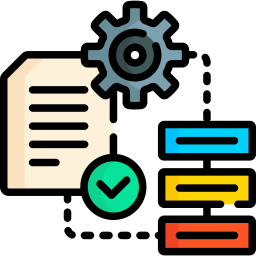

In [ ]:
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Descargar las stopwords de NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the missing resource

# Función para limpiar el texto
def clean_text(text):

    # NORMALIZACIÓN
    # Eliminar las etiquetas HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    # Signos y Caracteres - Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Conversión a minúscula - Convertir el texto
    text = text.lower()

    #TOKENIZACIÓN
    #Elementos básicos individuales de un texto.
    words = word_tokenize(text)

    # STOP WORDS
    # Eliminar palabras comunes en un idioma que no aportan significado, como por ejemplo: "el", "y", "a", etc.
    stop_words = set(stopwords.words('english')) #Palabras vacias en Ingles
    filtered_words = [word for word in words if word not in stop_words]

    # NORMALIZACIÓN - Lematización
    # Reduce las palabras a su forma de diccionario, ejemplo: "correr", "corriendo" y "Corrió" se normalizan a "Correr"
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]
    return ' '.join(lemmatized_words)

# Aplicar la función de limpieza al DataFrame
train_df['clean_review'] = train_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)

# Mostrar las transformaciones
train_df[['review', 'clean_review']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,review,clean_review
0,"If you like Star Wars/Trek, come see where the...",like star war trek come see got idea cinematic...
1,Here's another film that doesn't really need m...,another film really need much recommendation c...
2,I spied this short on a DVD of best new Zealan...,spied short dvd best new zealand short great f...
3,"The late, great Robert Bloch (author of PSYCHO...",late great robert bloch author psycho paying a...
4,"When plague breaks out in New Orleans, it's Ri...",plague break new orleans richard widmark rescu...


## Word Clouds


Una "nube de palabras" visualiza las palabras más frecuentes de un texto, con el tamaño de cada palabra proporcional a su frecuencia. Este tipo de visualización es útil para obtener una impresión rápida de los temas más discutidos en el dataset.

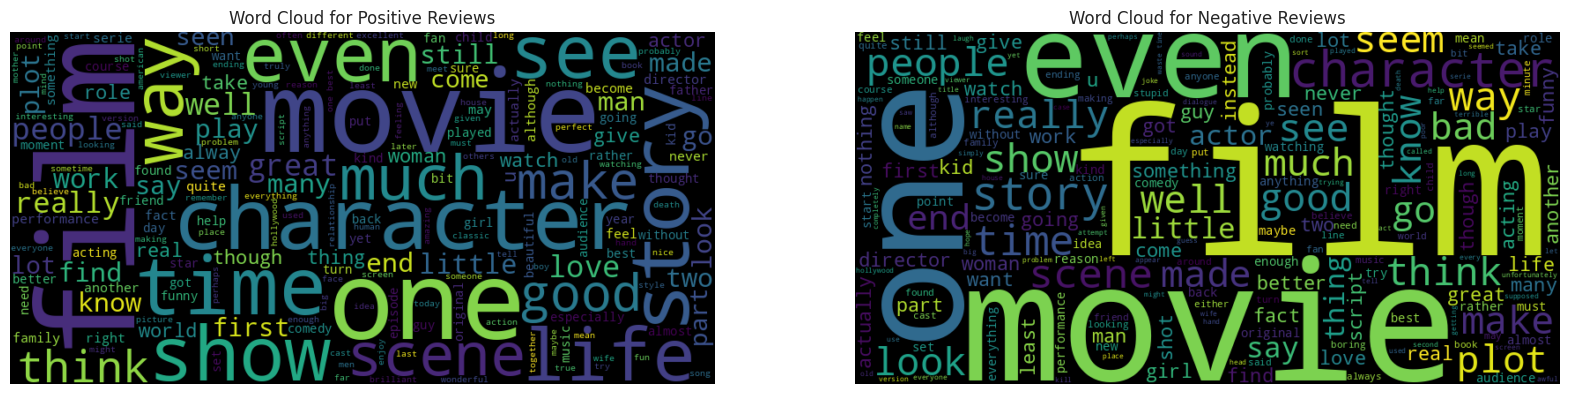

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generar una word cloud para las reseñas positivas
positive_text = ' '.join(train_df[train_df['label'] == 1]['clean_review'])
wordcloud_pos = WordCloud(width=800, height=400).generate(positive_text)

# Generar una word cloud para las reseñas negativas
negative_text = ' '.join(train_df[train_df['label'] == 0]['clean_review'])
wordcloud_neg = WordCloud(width=800, height=400).generate(negative_text)

# Visualización
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Word Cloud for Positive Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Word Cloud for Negative Reviews')
plt.axis('off')
plt.show()

# Extracción de Características


Convertiremos el texto limpio en formatos numéricos que los modelos de machine learning pueden procesar utilizando diferentes técnicas de vectorización.

### BAG OF WORDS - Extracción de Características
Crea un vocabulario de todas las palabras únicas en el dataset y usa la frecuencia de las palabras como características. Es simple pero efectiva para muchos problemas de NLP.

Otras técnicas de extracción de caracteristicas son por ejemplo:

*   **TF-IDF**: Similar a BoW pero ajusta las frecuencias según la importancia de las palabras en los documentos. Es útil para resaltar palabras que son más relevantes en un contexto específico.
*   **Words Embeddings**: Conjunto de modelos de lenguaje y técnicas de aprendizaje en procesamiento del lenguaje natural en donde las palabras o frases del lenguaje natural son representadas como vectores de números reales (Word2vec, GLOVE)

La elección entre ellas depende del contexto específico y de los objetivos del análisis.

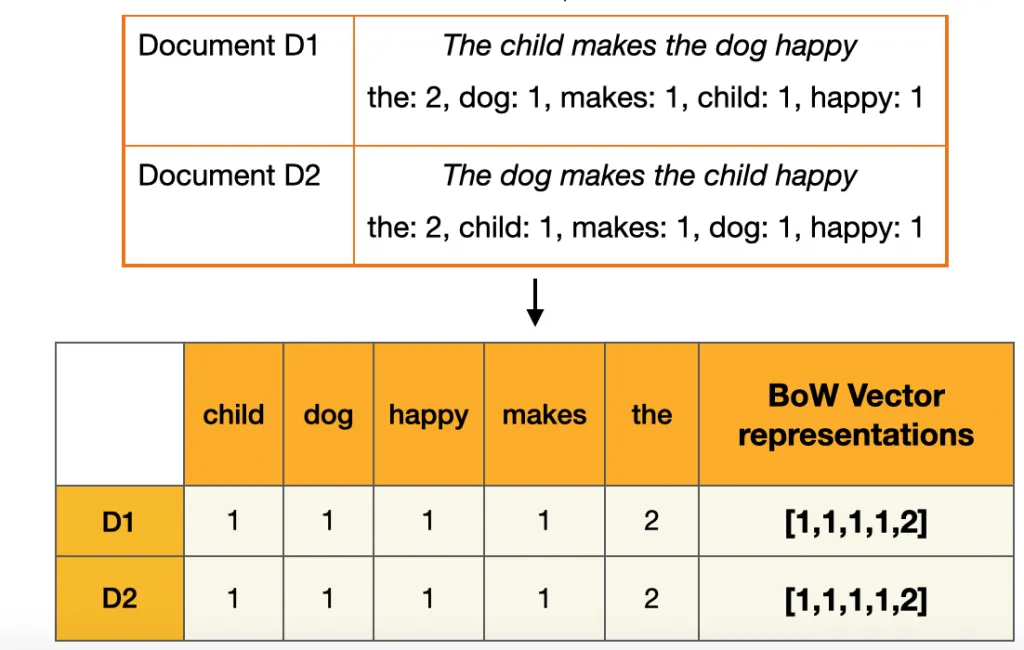

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Bag of Words
vectorizer_bow = CountVectorizer()
X_bow_train = vectorizer_bow.fit_transform(train_df['clean_review'])
X_bow_test = vectorizer_bow.transform(test_df['clean_review'])


# Comparación de características extraídas
print("Número de características en BoW:", X_bow_train.shape[1])


Número de características en BoW: 66479


## Visualización de características para cada review - BoW

In [ ]:
import pandas as pd

# Obteniendo nombres de las características (palabras) para BoW
feature_names_bow = vectorizer_bow.get_feature_names_out()

# Convertir una fila de la matriz BoW a DataFrame para una visualización más fácil
def bow_to_df(row_index):
    row = X_bow_train[row_index].toarray().flatten()  # Convierte a array y aplana
    df = pd.DataFrame({'Word': feature_names_bow, 'Frequency': row})
    return df[df['Frequency'] > 0]  # Filtrar por frecuencias mayores a cero

# Visualizar la conversión BoW de una revisión específica
example_bow = bow_to_df(0)  # Cambia 0 por otro índice si es necesario
print(train_df['clean_review'][0])
example_bow

like star war trek come see got idea cinematic device top favorite movie time worldly futuristic psycho thriller intensity root material shakespeare tempest overshadowed whizbang gimmickry la later lucas made assume see string holding flying saucer first movie miracle made movie scale economics taste time stacked heavily director wilcox previous hit lassie come home looked assumed fred wilcox pseudonym director already later became famous time want associated sci fi strictly b genre back either visionary production fortuitous mistake part folk bankroll hollywood massive scale matte live action almost microscopically inserted lucas used extensively intelligent machine transcend stereotypical user interface computer come portrayed much less futuristically later work star trek transporter visually almost unaltered roddenberry year later trek war technobabble turn fp scientific reference overdone accurate even today ship set comprehensive sparklingly realistic good anything seen since conv

,Word,Frequency
366,accurate,1
484,action,1
1533,almost,2
1577,already,1
2425,anything,2
...,...,...
65251,wondered,1
65366,work,1
65400,worldly,1
65450,would,1


## Visualización de distribución de palabras - BoW

/tmp/ipython-input-3165589418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df, palette='PuBuGn_d')


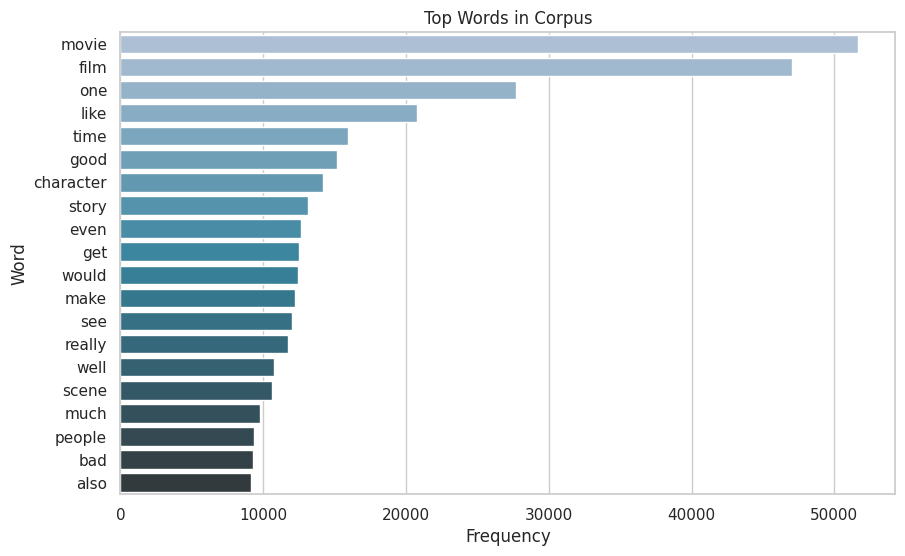

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_words(vectorizer, feature_matrix, top_n=20):
    sum_words = feature_matrix.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]
    df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Frequency', y='Word', data=df, palette='PuBuGn_d')
    plt.title('Top Words in Corpus')
    plt.show()

# Ejemplo de uso con BoW
plot_top_words(vectorizer_bow, X_bow_train)

## REGRESIÓN LOGISTICA - Machine Learning Tradicional (basado en BoW)

La regresión logística es un algoritmo de clasificación utilizado para predecir la probabilidad de que una instancia pertenezca a una clase particular. La regresión logística predice un resultado binario (por ejemplo, 0 o 1, verdadero o falso, positivo o negativo).

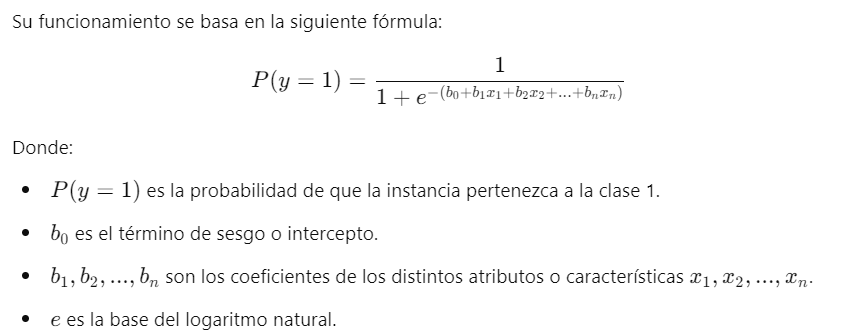

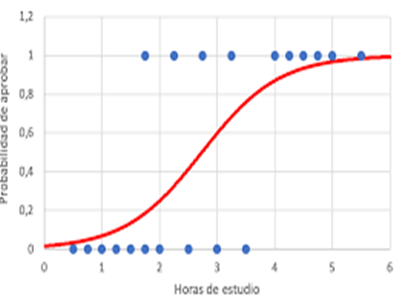

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Se crea una instancia del modelo de regresión logística.
model = LogisticRegression()
# Entrenamiento del modelo
# X_BOW_TRAIN set de datos para entrenamiento, la columna "label" es la etiqueda de sentimiento
model.fit(X_bow_train, train_df['label'])

# Evaluación del modelo
predictions = model.predict(X_bow_test)
print(classification_report(test_df['label'], predictions))


              precision    recall  f1-score   support

           0       0.85      0.87      0.86     12500
           1       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



**Precisión (Precision):**

*   La precisión para la clase 0 es 0.85. Esto significa que, de todas las
instancias que el modelo predijo como clase 0, el 85% realmente pertenecían a la clase 0.
*   Para la clase 1, la precisión es 0.87, lo que indica que el 87% de las instancias predichas como clase 1 eran correctas.

**Exhaustividad (Recall)**


*   La exhaustividad (también conocida como "sensibilidad") para la clase 0 es 0.87, lo que significa que el 87% de las instancias que eran realmente de la clase 0 fueron correctamente identificadas por el modelo.
*   Para la clase 1, la exhaustividad es 0.85, es decir, el 85% de las instancias que realmente pertenecían a la clase 1 fueron correctamente clasificadas.

**F1-score:**


*   El F1-score es la media armónica entre la precisión y la exhaustividad. Es útil cuando tienes un desequilibrio entre las clases, ya que combina ambas métricas en una sola.
Para la clase 0, el F1-score es 0.86, y para la clase 1 es 0.86.

**Exactitud (Accuracy):**

*   La exactitud es la fracción de predicciones correctas en el conjunto de prueba. En este caso, la exactitud es 0.86, lo que significa que el modelo acertó el 86% de las predicciones totales.







